<a href="https://colab.research.google.com/github/Mrsayem/Technical-Assessments-/blob/main/inria_building_competition_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install -U "segmentation-models-pytorch>=0.5.0" "timm>=1.0" "rasterio>=1.3" "huggingface_hub>=0.25"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 23.9 MB/s eta 0:00:00


##GPU and disk checks

In [ ]:
import os
import gc
import json
import math
import random
import shutil
import warnings
from copy import deepcopy
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import segmentation_models_pytorch as smp
import rasterio
from rasterio.windows import Window
from rasterio.enums import Resampling
from scipy import ndimage
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=rasterio.errors.NotGeoreferencedWarning)

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_GB = 0.0
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    GPU_GB = props.total_memory / 1024**3
    print("GPU:", props.name)
    print(f"GPU memory: {GPU_GB:.1f} GB")
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
else:
    print("WARNING: GPU is not enabled. Training this notebook on CPU is impractical.")

root_for_disk = "/content" if Path("/content").exists() else "/"
disk = shutil.disk_usage(root_for_disk)
print(f"Free local disk: {disk.free / 1024**3:.1f} GB")

Device: cuda
GPU: Tesla T4
GPU memory: 14.6 GB
Free local disk: 65.2 GB


In [ ]:

PATCH_SIZE = 512
INDEX_STRIDE = 256

DEV_TRAIN_CITIES = ["austin", "chicago", "vienna"]
DEV_VAL_CITIES   = ["kitsap"]
TEST_CITIES      = ["tyrol-w"]
FINAL_TRAIN_CITIES = DEV_TRAIN_CITIES + DEV_VAL_CITIES
EXPECTED_TILES_PER_CITY = 36


SMOKE_TEST = False
RUN_DEV_TRAINING = True
RUN_VALIDATION_CACHE = False
RUN_FINAL_REFIT = False
RUN_TEST_CACHE = True


RESUME_TRAINING = False


MAX_DEV_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
WARMUP_EPOCHS = 2
ENCODER_LR = 1e-5
HEAD_LR = 5e-5
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0


PHYSICAL_BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 2

TRAIN_SAMPLES_PER_EPOCH = 3000
FINAL_SAMPLES_PER_EPOCH = 10000


BCE_WEIGHT = 0.30
DICE_WEIGHT = 0.30
LOVASZ_WEIGHT = 0.30
BOUNDARY_WEIGHT = 0.10


INFER_STRIDE = 256
TTA_MODE = "4way"
INFERENCE_BATCH_SIZE = PHYSICAL_BATCH_SIZE
BOUNDARY_TOLERANCE_PX = 3


ENSEMBLE_WEIGHTS = np.round(np.arange(0.0, 1.001, 0.05), 2)
THRESHOLDS = np.round(np.arange(0.20, 0.901, 0.01), 2)
TUNING_SAMPLE_PIXELS_PER_TILE = 100_000


TUNE_POSTPROCESS = False
POSTPROCESS_CANDIDATES = [0, 8, 16, 32, 64]
MIN_COMPONENT_AREA = 0


HIGH_COMPUTE = GPU_GB >= 24

MODEL_SPECS = {
    "deeplab_convnext": {
        "arch": "deeplabv3plus",
        "encoder": "tu-convnext_small" if HIGH_COMPUTE else "tu-convnext_tiny",
    },
    "segformer_mit": {
        "arch": "segformer",
        "encoder": "mit_b3" if HIGH_COMPUTE else "mit_b2",
    },
}

if SMOKE_TEST:
    MAX_DEV_EPOCHS = 1
    TRAIN_SAMPLES_PER_EPOCH = 64
    FINAL_SAMPLES_PER_EPOCH = 64
    TUNING_SAMPLE_PIXELS_PER_TILE = 20_000

print(json.dumps({
    "patch_size": PATCH_SIZE,
    "dev_train": DEV_TRAIN_CITIES,
    "validation": DEV_VAL_CITIES,
    "test": TEST_CITIES,
    "models": MODEL_SPECS,
    "batch": PHYSICAL_BATCH_SIZE,
    "effective_batch": PHYSICAL_BATCH_SIZE * GRAD_ACCUM_STEPS,
    "infer_stride": INFER_STRIDE,
    "tta": TTA_MODE,
    "smoke_test": SMOKE_TEST,
}, indent=2))

{
  "patch_size": 512,
  "dev_train": [
    "austin",
    "chicago",
    "vienna"
  ],
  "validation": [
    "kitsap"
  ],
  "test": [
    "tyrol-w"
  ],
  "models": {
    "deeplab_convnext": {
      "arch": "deeplabv3plus",
      "encoder": "tu-convnext_tiny"
    },
    "segformer_mit": {
      "arch": "segformer",
      "encoder": "mit_b2"
    }
  },
  "batch": 2,
  "effective_batch": 4,
  "infer_stride": 256,
  "tta": "4way",
  "smoke_test": false
}


In [ ]:
RUN_TAG = "smoke_v2" if SMOKE_TEST else "competition_v2"
SAVE_ROOT = Path(f"/content/inria_{RUN_TAG}")

try:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_ROOT = Path(f"/content/drive/MyDrive/inria_building_{RUN_TAG}")
except Exception as e:
    print("Google Drive not mounted; using local output folder.")
    print("Reason:", e)

SAVE_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = Path(f"/content/inria_prediction_cache_{RUN_TAG}")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("Persistent outputs:", SAVE_ROOT)
print("Local prediction cache:", CACHE_ROOT)

Mounted at /content/drive
Persistent outputs: /content/drive/MyDrive/inria_building_competition_v2
Local prediction cache: /content/inria_prediction_cache_competition_v2


In [ ]:
from huggingface_hub import snapshot_download

DATA_DOWNLOAD_ROOT = Path("/content/inria_download")
DATA_DOWNLOAD_ROOT.mkdir(parents=True, exist_ok=True)
HF_REPO = "blanchon/INRIA-Aerial-Image-Labeling"

if not (DATA_DOWNLOAD_ROOT / "data" / "train" / "images").exists():
    print("Downloading labelled Inria imagery + ground-truth masks...")
    snapshot_download(
        repo_id=HF_REPO,
        repo_type="dataset",
        local_dir=str(DATA_DOWNLOAD_ROOT),
        allow_patterns=[
            "data/train/images/*.tif",
            "data/train/gt/*.tif",
        ],
        max_workers=4,
    )
else:
    print("Dataset folder already exists; skipping download.")

DATASET_ROOT = DATA_DOWNLOAD_ROOT / "data"
TRAIN_IMAGE_DIR = DATASET_ROOT / "train" / "images"
TRAIN_MASK_DIR = DATASET_ROOT / "train" / "gt"
print(TRAIN_IMAGE_DIR)
print(TRAIN_MASK_DIR)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 360 files:   0%|          | 0/360 [00:00<?, ?it/s]

/content/inria_download/data/train/images
/content/inria_download/data/train/gt


In [ ]:
def city_from_name(filename: str) -> str:
    stem = Path(filename).stem.lower()
    for city in ["tyrol-w", "austin", "chicago", "kitsap", "vienna"]:
        if stem.startswith(city):
            return city
    raise ValueError(f"Unknown city prefix: {filename}")

image_paths = sorted(TRAIN_IMAGE_DIR.glob("*.tif"))
mask_paths = sorted(TRAIN_MASK_DIR.glob("*.tif"))

assert len(image_paths) == 180, f"Expected 180 labelled images, found {len(image_paths)}"
assert len(mask_paths) == 180, f"Expected 180 masks, found {len(mask_paths)}"
assert {p.name for p in image_paths} == {p.name for p in mask_paths}

city_counts = defaultdict(int)
rows = []
for p in image_paths:
    city = city_from_name(p.name)
    city_counts[city] += 1
    rows.append({
        "city": city,
        "tile": p.stem,
        "image": str(p),
        "mask": str(TRAIN_MASK_DIR / p.name),
    })

for city in ["austin", "chicago", "kitsap", "vienna", "tyrol-w"]:
    assert city_counts[city] == EXPECTED_TILES_PER_CITY

pairs_df = pd.DataFrame(rows)
dev_train_pairs = pairs_df[pairs_df.city.isin(DEV_TRAIN_CITIES)].reset_index(drop=True)
dev_val_pairs   = pairs_df[pairs_df.city.isin(DEV_VAL_CITIES)].reset_index(drop=True)
test_pairs      = pairs_df[pairs_df.city.isin(TEST_CITIES)].reset_index(drop=True)
final_train_pairs = pairs_df[pairs_df.city.isin(FINAL_TRAIN_CITIES)].reset_index(drop=True)

assert len(dev_train_pairs) == 108
assert len(dev_val_pairs) == 36
assert len(test_pairs) == 36
assert len(final_train_pairs) == 144

assert set(dev_train_pairs.city).isdisjoint(set(dev_val_pairs.city))
assert set(dev_train_pairs.city).isdisjoint(set(test_pairs.city))
assert set(dev_val_pairs.city).isdisjoint(set(test_pairs.city))

if SMOKE_TEST:
    dev_train_pairs_run = dev_train_pairs.groupby("city", group_keys=False).head(1).reset_index(drop=True)
    dev_val_pairs_run = dev_val_pairs.head(1).reset_index(drop=True)
    test_pairs_run = test_pairs.head(1).reset_index(drop=True)
    final_train_pairs_run = final_train_pairs.groupby("city", group_keys=False).head(1).reset_index(drop=True)
else:
    dev_train_pairs_run = dev_train_pairs
    dev_val_pairs_run = dev_val_pairs
    test_pairs_run = test_pairs
    final_train_pairs_run = final_train_pairs

split_manifest = pairs_df.copy()
split_manifest["split"] = split_manifest["city"].map({
    **{c: "development_train" for c in DEV_TRAIN_CITIES},
    **{c: "development_validation" for c in DEV_VAL_CITIES},
    **{c: "final_test" for c in TEST_CITIES},
})
split_manifest.to_csv(SAVE_ROOT / "split_manifest.csv", index=False)

print("Tiles by city:", dict(city_counts))
print("Development train:", len(dev_train_pairs_run))
print("Validation       :", len(dev_val_pairs_run))
print("Final test       :", len(test_pairs_run))
print("Final refit pool :", len(final_train_pairs_run))

Tiles by city: {'austin': 36, 'chicago': 36, 'kitsap': 36, 'tyrol-w': 36, 'vienna': 36}
Development train: 108
Validation       : 36
Final test       : 36
Final refit pool : 144


## 7. Visual sanity check

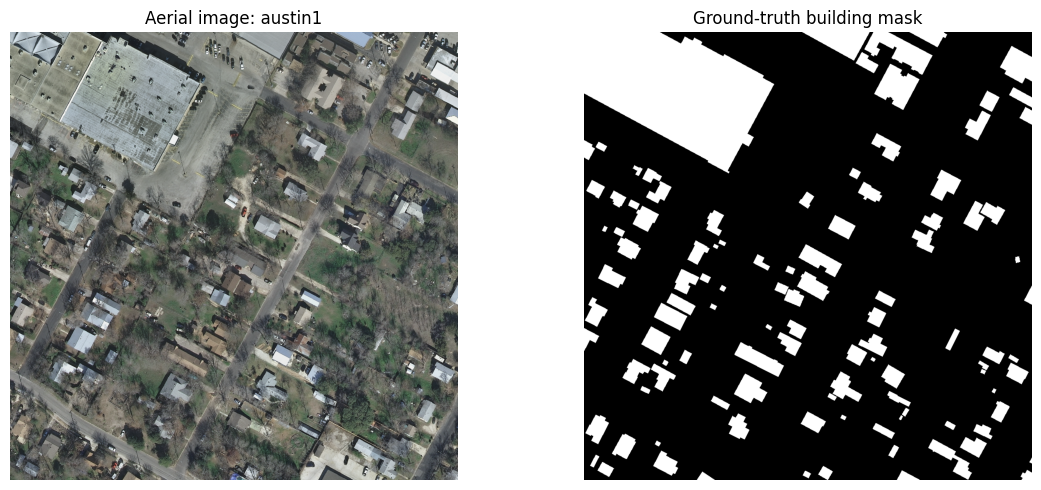

In [ ]:
row = dev_train_pairs_run.iloc[0]
win = Window(1500, 1500, 1024, 1024)

with rasterio.open(row["image"]) as src:
    img = src.read([1,2,3], window=win).transpose(1,2,0)

with rasterio.open(row["mask"]) as src:
    mask = src.read(1, window=win) > 127

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f"Aerial image: {row['tile']}")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Ground-truth building mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def sliding_starts_for_index(size=5000, patch=PATCH_SIZE, stride=INDEX_STRIDE):
    starts = list(range(0, size - patch + 1, stride))
    final_start = size - patch
    if not starts or starts[-1] != final_start:
        starts.append(final_start)
    return starts

INDEX_STARTS = sliding_starts_for_index()
print("Candidate starts per axis:", len(INDEX_STARTS))
print("Candidate patches per tile:", len(INDEX_STARTS) ** 2)

def lowres_mask(mask_path, out_size=625):
    with rasterio.open(mask_path) as src:
        arr = src.read(1, out_shape=(out_size, out_size), resampling=Resampling.nearest)
    return (arr > 127).astype(np.uint8)

def estimate_window_fg(low_mask, x, y, patch=PATCH_SIZE, original_size=5000):
    h, w = low_mask.shape
    sx, sy = w / original_size, h / original_size
    x0, y0 = int(round(x*sx)), int(round(y*sy))
    x1 = min(w, int(round((x+patch)*sx)))
    y1 = min(h, int(round((y+patch)*sy)))
    crop = low_mask[y0:y1, x0:x1]
    return float(crop.mean()) if crop.size else 0.0

def build_patch_index(pairs, stride=INDEX_STRIDE):
    rows = []
    starts = sliding_starts_for_index(stride=stride)
    for row in tqdm(pairs.itertuples(index=False), total=len(pairs), desc=f"Indexing patches (stride={stride})"):
        lm = lowres_mask(row.mask)
        for y in starts:
            for x in starts:
                rows.append({
                    "city": row.city,
                    "tile": row.tile,
                    "image": row.image,
                    "mask": row.mask,
                    "x": x,
                    "y": y,
                    "fg_ratio": estimate_window_fg(lm, x, y),
                })
    return pd.DataFrame(rows)

dev_train_index = build_patch_index(dev_train_pairs_run, stride=INDEX_STRIDE)
dev_val_index = build_patch_index(dev_val_pairs_run, stride=PATCH_SIZE)  # cheaper checkpoint validation
final_train_index = build_patch_index(final_train_pairs_run, stride=INDEX_STRIDE) if RUN_FINAL_REFIT else None

print("Development train candidates:", len(dev_train_index))
print("Validation candidates       :", len(dev_val_index))
if final_train_index is not None:
    print("Final refit candidates      :", len(final_train_index))

display(dev_train_index.fg_ratio.describe(percentiles=[.25,.5,.75,.9,.95]))

Candidate starts per axis: 19
Candidate patches per tile: 361


Indexing patches (stride=256):   0%|          | 0/108 [00:00<?, ?it/s]

Indexing patches (stride=512):   0%|          | 0/36 [00:00<?, ?it/s]

Development train candidates: 38988
Validation candidates       : 3600


,fg_ratio
count,38988.000000
mean,0.227214
std,0.161674
min,0.000000
25%,0.104248
50%,0.205566
75%,0.334961
90%,0.462891
95%,0.520752
max,1.000000


In [ ]:
def estimate_global_pos_weight(pairs, out_size=500):
    positives = 0
    total = 0
    for row in tqdm(pairs.itertuples(index=False), total=len(pairs), desc="Estimating class balance"):
        with rasterio.open(row.mask) as src:
            m = src.read(1, out_shape=(out_size, out_size), resampling=Resampling.nearest) > 127
        positives += int(m.sum())
        total += int(m.size)
    frac = positives / max(total, 1)
    raw = (total - positives) / max(positives, 1)
    return frac, float(np.clip(raw, 1.0, 3.0))

DEV_FOREGROUND_FRACTION, DEV_POS_WEIGHT = estimate_global_pos_weight(dev_train_pairs_run)
FINAL_FOREGROUND_FRACTION, FINAL_POS_WEIGHT = (
    estimate_global_pos_weight(final_train_pairs_run) if RUN_FINAL_REFIT
    else (DEV_FOREGROUND_FRACTION, DEV_POS_WEIGHT)
)

print(f"Development foreground fraction: {DEV_FOREGROUND_FRACTION:.4f}")
print(f"Development BCE pos_weight     : {DEV_POS_WEIGHT:.3f}")
print(f"Final-refit BCE pos_weight      : {FINAL_POS_WEIGHT:.3f}")

Estimating class balance:   0%|          | 0/108 [00:00<?, ?it/s]

Development foreground fraction: 0.2274
Development BCE pos_weight     : 3.000
Final-refit BCE pos_weight      : 3.000


In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

class InriaPatchDataset(Dataset):
    def __init__(self, index_df, augment=False):
        self.records = index_df.to_dict("records")
        self.augment = augment
        self._img_handles = {}
        self._mask_handles = {}

    def __len__(self):
        return len(self.records)

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_img_handles"] = {}
        state["_mask_handles"] = {}
        return state

    def _get_handle(self, path, store):
        if path not in store:
            store[path] = rasterio.open(path)
        return store[path]

    def _augment(self, img, mask):

        if random.random() < 0.5:
            img = torch.flip(img, dims=[2])
            mask = torch.flip(mask, dims=[2])

        if random.random() < 0.5:
            img = torch.flip(img, dims=[1])
            mask = torch.flip(mask, dims=[1])

        k = random.randint(0, 3)

        if k:
            img = torch.rot90(img, k=k, dims=[1, 2])
            mask = torch.rot90(mask, k=k, dims=[1, 2])
        if random.random() < 0.80:

            brightness = random.uniform(0.75, 1.25)
            contrast = random.uniform(0.75, 1.25)

            mean = img.mean(
                dim=(1, 2),
                keepdim=True
            )

            img = (img - mean) * contrast + mean
            img = img * brightness
        if random.random() < 0.50:

            channel_gain = torch.tensor(
                [
                    random.uniform(0.85, 1.15),
                    random.uniform(0.85, 1.15),
                    random.uniform(0.85, 1.15),
                ],
                dtype=img.dtype
            ).view(3, 1, 1)

            img = img * channel_gain
        if random.random() < 0.35:

            saturation = random.uniform(0.70, 1.30)

            gray = img.mean(
                dim=0,
                keepdim=True
            )

            img = gray + saturation * (img - gray)

        if random.random() < 0.35:

            gamma = random.uniform(0.70, 1.40)

            img = img.clamp(0, 1).pow(gamma)


        if random.random() < 0.15:

            img = F.avg_pool2d(
                img.unsqueeze(0),
                kernel_size=3,
                stride=1,
                padding=1
            ).squeeze(0)



        if random.random() < 0.20:

            noise_std = random.uniform(
                0.003,
                0.02
            )

            img = img + torch.randn_like(img) * noise_std


        return img.clamp(0.0, 1.0), mask

    def __getitem__(self, idx):
        r = self.records[idx]
        window = Window(r["x"], r["y"], PATCH_SIZE, PATCH_SIZE)
        img_src = self._get_handle(r["image"], self._img_handles)
        mask_src = self._get_handle(r["mask"], self._mask_handles)

        img = img_src.read([1,2,3], window=window)
        mask = mask_src.read(1, window=window)

        img = torch.from_numpy(img.astype(np.float32) / 255.0)
        mask = torch.from_numpy((mask > 127).astype(np.float32)).unsqueeze(0)

        if self.augment:
            img, mask = self._augment(img, mask)

        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        return img, mask


# def stratified_sampler_weights(index_df):
#     fg = index_df.fg_ratio.to_numpy()
#     # 0=background, 1=sparse, 2=mixed, 3=rich
#     bins = np.select(
#         [fg < 0.001, fg < 0.03, fg < 0.35],
#         [0, 1, 2],
#         default=3,
#     )
#     target_prob = {0: 0.25, 1: 0.20, 2: 0.40, 3: 0.15}
#     counts = {b: max(int((bins == b).sum()), 1) for b in range(4)}
#     weights = np.array([target_prob[int(b)] / counts[int(b)] for b in bins], dtype=np.float64)
#     return weights, bins
def stratified_sampler_weights(index_df):
    fg = index_df.fg_ratio.to_numpy()

    bins = np.select(
        [
            fg < 0.0002,
            fg < 0.01,
            fg < 0.05,
            fg < 0.25,
        ],
        [0, 1, 2, 3],
        default=4,
    )

    target_prob = {
        0: 0.05,
        1: 0.10,
        2: 0.20,
        3: 0.40,
        4: 0.25,
    }

    counts = {
        b: max(int((bins == b).sum()), 1)
        for b in range(5)
    }

    weights = np.array(
        [
            target_prob[int(b)] / counts[int(b)]
            for b in bins
        ],
        dtype=np.float64
    )

    return weights, bins


def make_loaders(train_index, val_index=None, samples_per_epoch=TRAIN_SAMPLES_PER_EPOCH):
    train_ds = InriaPatchDataset(train_index, augment=True)
    weights, bins = stratified_sampler_weights(train_index)
    sampler = WeightedRandomSampler(
        torch.as_tensor(weights, dtype=torch.double),
        num_samples=max(int(samples_per_epoch), 1),
        replacement=True,
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=PHYSICAL_BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=True,
    )

    val_loader = None
    if val_index is not None:
        val_ds = InriaPatchDataset(val_index, augment=False)
        val_loader = DataLoader(
            val_ds,
            batch_size=PHYSICAL_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=(DEVICE.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
        )

    print(
    "Sampler candidate-bin counts:",
    {i: int((bins == i).sum()) for i in range(5)}
    )
    return train_loader, val_loader

dev_train_loader, dev_val_loader = make_loaders(dev_train_index, dev_val_index)
xb, yb = next(iter(dev_train_loader))
print("Batch image:", xb.shape, xb.dtype)
print("Batch mask :", yb.shape, yb.dtype, "values=", torch.unique(yb))

Sampler candidate-bin counts: {0: 2755, 1: 1194, 2: 2445, 3: 17107, 4: 15487}
Batch image: torch.Size([2, 3, 512, 512]) torch.float32
Batch mask : torch.Size([2, 1, 512, 512]) torch.float32 values= tensor([0., 1.])


In [ ]:
def build_model(model_key, pretrained=True):
    spec = MODEL_SPECS[model_key]
    weights = "imagenet" if pretrained else None

    if spec["arch"] == "deeplabv3plus":
        model = smp.DeepLabV3Plus(
            encoder_name=spec["encoder"],
            encoder_weights=weights,
            encoder_output_stride=16,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif spec["arch"] == "segformer":
        model = smp.Segformer(
            encoder_name=spec["encoder"],
            encoder_weights=weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    else:
        raise ValueError(spec)

    return model

for key in MODEL_SPECS:
    m = build_model(key, pretrained=False)
    params = sum(p.numel() for p in m.parameters())
    print(f"{key}: {MODEL_SPECS[key]} | params={params/1e6:.1f}M")
    del m

deeplab_convnext: {'arch': 'deeplabv3plus', 'encoder': 'tu-convnext_tiny'} | params=29.3M
segformer_mit: {'arch': 'segformer', 'encoder': 'mit_b2'} | params=24.7M


In [ ]:
class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        dims = (1,2,3)
        inter = (probs * targets).sum(dims)
        denom = probs.sum(dims) + targets.sum(dims)
        dice = (2*inter + self.smooth) / (denom + self.smooth)
        return 1.0 - dice.mean()

def soft_boundary(x, kernel_size=3):
    pad = kernel_size // 2
    dil = F.max_pool2d(x, kernel_size, 1, pad)
    ero = -F.max_pool2d(-x, kernel_size, 1, pad)
    return (dil - ero).clamp(0,1)

class BoundaryDiceLoss(nn.Module):
    def __init__(self, smooth=1.0, kernel_size=3):
        super().__init__(); self.smooth=smooth; self.kernel_size=kernel_size
    def forward(self, logits, targets):
        pb = soft_boundary(torch.sigmoid(logits), self.kernel_size)
        tb = soft_boundary(targets, self.kernel_size)
        dims=(1,2,3)
        inter=(pb*tb).sum(dims)
        denom=pb.sum(dims)+tb.sum(dims)
        return 1.0 - ((2*inter+self.smooth)/(denom+self.smooth)).mean()

class CompetitionLoss(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.register_buffer("pos_weight", torch.tensor([pos_weight], dtype=torch.float32))
        self.dice = SoftDiceLoss()
        self.lovasz = smp.losses.LovaszLoss(mode="binary", per_image=False, from_logits=True)
        self.boundary = BoundaryDiceLoss()

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=self.pos_weight)
        dice = self.dice(logits, targets)
        lovasz = self.lovasz(logits, targets)
        boundary = self.boundary(logits, targets)
        total = (
            BCE_WEIGHT*bce + DICE_WEIGHT*dice +
            LOVASZ_WEIGHT*lovasz + BOUNDARY_WEIGHT*boundary
        )
        return total, {
            "bce": bce.detach(), "dice": dice.detach(),
            "lovasz": lovasz.detach(), "boundary": boundary.detach(),
        }

In [ ]:
def metrics_from_counts(tp, fp, fn, tn, eps=1e-8):
    return {
        "iou": tp / (tp+fp+fn+eps),
        "dice": 2*tp / (2*tp+fp+fn+eps),
        "precision": tp / (tp+fp+eps),
        "recall": tp / (tp+fn+eps),
        "accuracy": (tp+tn) / (tp+tn+fp+fn+eps),
    }

def binary_counts_from_logits(logits, targets, threshold=0.5):
    pred = torch.sigmoid(logits) >= threshold
    true = targets >= 0.5
    return (
        int(torch.logical_and(pred, true).sum().item()),
        int(torch.logical_and(pred, ~true).sum().item()),
        int(torch.logical_and(~pred, true).sum().item()),
        int(torch.logical_and(~pred, ~true).sum().item()),
    )

AMP_ENABLED = DEVICE.type == "cuda"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

def autocast_context():
    if hasattr(torch, "amp") and hasattr(torch.amp, "autocast"):
        return torch.amp.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
            enabled=AMP_ENABLED,
        )
    return torch.cuda.amp.autocast(enabled=AMP_ENABLED)

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def make_optimizer_and_scheduler(model, total_epochs):
    encoder_params = list(model.encoder.parameters())
    encoder_ids = {id(p) for p in encoder_params}
    head_params = [p for p in model.parameters() if id(p) not in encoder_ids]

    optimizer = torch.optim.AdamW([
        {"params": encoder_params, "lr": ENCODER_LR},
        {"params": head_params, "lr": HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)

    warm = min(WARMUP_EPOCHS, max(total_epochs-1, 0))
    if warm > 0:
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.2, end_factor=1.0, total_iters=warm
        )
        cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(total_epochs-warm, 1), eta_min=1e-6
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine], milestones=[warm]
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(total_epochs,1), eta_min=1e-6
        )
    return optimizer, scheduler

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running = 0.0; seen = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (images, masks) in enumerate(tqdm(loader, desc="Train", leave=False), start=1):
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        with autocast_context():
            logits = model(images)
            loss, _ = criterion(logits, masks)
            scaled = loss / GRAD_ACCUM_STEPS
        scaler.scale(scaled).backward()

        if step % GRAD_ACCUM_STEPS == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        bs = images.size(0)
        running += float(loss.detach()) * bs
        seen += bs
    return running / max(seen,1)

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, threshold=0.5):
    model.eval()
    running=0.0; seen=0; tp=fp=fn=tn=0
    for images, masks in tqdm(loader, desc="Validate", leave=False):
        images=images.to(DEVICE, non_blocking=True)
        masks=masks.to(DEVICE, non_blocking=True)
        with autocast_context():
            logits=model(images)
            loss,_=criterion(logits,masks)
        bs=images.size(0)
        running += float(loss)*bs; seen += bs
        c=binary_counts_from_logits(logits,masks,threshold)
        tp+=c[0]; fp+=c[1]; fn+=c[2]; tn+=c[3]
    out=metrics_from_counts(tp,fp,fn,tn)
    out["loss"] = running/max(seen,1)
    return out

def train_development_model(model_key, train_loader, val_loader, pos_weight):
    model_dir = SAVE_ROOT / "development" / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    best_path = model_dir / "best.pt"
    last_path = model_dir / "last.pt"
    history_path = model_dir / "history.csv"

    model = build_model(model_key, pretrained=True).to(DEVICE)
    criterion = CompetitionLoss(pos_weight).to(DEVICE)
    optimizer, scheduler = make_optimizer_and_scheduler(model, MAX_DEV_EPOCHS)

    history=[]; start_epoch=1; best_iou=-1.0; stale=0
    if RESUME_TRAINING and last_path.exists():
        ckpt=safe_torch_load(last_path, DEVICE)
        if ckpt.get("model_spec") not in (None, MODEL_SPECS[model_key]):
            raise RuntimeError(f"Checkpoint architecture mismatch for {model_key}. Use a fresh experiment folder.")
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        try:
          scheduler.load_state_dict(ckpt["scheduler"])
        except KeyError as e:
          print(f"Warning: could not load scheduler state ({e}). Starting with a new scheduler.")
        if "scaler" in ckpt: scaler.load_state_dict(ckpt["scaler"])
        history=ckpt.get("history",[])
        start_epoch=ckpt["epoch"]+1
        best_iou=ckpt.get("best_iou",-1.0)
        stale=ckpt.get("stale",0)
        print(f"Resuming {model_key} from epoch {start_epoch}")

    for epoch in range(start_epoch, MAX_DEV_EPOCHS+1):
        print(f"\n[{model_key}] Epoch {epoch}/{MAX_DEV_EPOCHS}")
        train_loss=train_one_epoch(model,train_loader,optimizer,criterion)
        val=validate_one_epoch(model,val_loader,criterion,threshold=0.5)
        scheduler.step()

        row={
            "epoch":epoch,"train_loss":train_loss,"val_loss":val["loss"],
            "val_iou_050":val["iou"],"val_dice_050":val["dice"],
            "val_precision_050":val["precision"],"val_recall_050":val["recall"],
            "encoder_lr":optimizer.param_groups[0]["lr"],
            "head_lr":optimizer.param_groups[1]["lr"],
        }
        history.append(row)
        pd.DataFrame(history).to_csv(history_path,index=False)
        print(row)

        improved = val["iou"] > best_iou + 1e-5
        if improved:
            best_iou=val["iou"]; stale=0
            torch.save({
                "epoch":epoch,"model":model.state_dict(),"best_iou":best_iou,
                "model_key":model_key,"model_spec":MODEL_SPECS[model_key],
                "pos_weight":pos_weight,
            }, best_path)
            print("Saved new best checkpoint.")
        else:
            stale += 1

        torch.save({
            "epoch":epoch,"model":model.state_dict(),"optimizer":optimizer.state_dict(),
            "scheduler":scheduler.state_dict(),"scaler":scaler.state_dict(),
            "history":history,"best_iou":best_iou,"stale":stale,
            "model_key":model_key,"model_spec":MODEL_SPECS[model_key],
        }, last_path)

        if stale >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

    del model, criterion, optimizer, scheduler
    gc.collect()
    if DEVICE.type=="cuda": torch.cuda.empty_cache()
    return best_path

In [ ]:
DEV_BEST_PATHS = {}

TRAIN_MODEL_KEYS = ["deeplab_convnext"] #deeplab_convnext or segformer_mit which ever model I wanna train

if RUN_DEV_TRAINING:
    for model_key in TRAIN_MODEL_KEYS:
        DEV_BEST_PATHS[model_key] = train_development_model(
            model_key,
            dev_train_loader,
            dev_val_loader,
            DEV_POS_WEIGHT
        )
else:
    for model_key in MODEL_SPECS:
        p = SAVE_ROOT / "development" / model_key / "best.pt"
        assert p.exists(), f"Missing {p}"
        DEV_BEST_PATHS[model_key] = p

print(DEV_BEST_PATHS)

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            


[deeplab_convnext] Epoch 1/20


Train:   0%|          | 0/1500 [00:00<?, ?it/s]

Validate:   0%|          | 0/1800 [00:00<?, ?it/s]

...

Validate:   0%|          | 0/1800 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 0.42515068862835564, 'val_loss': 0.6462411033527719, 'val_iou_050': 0.6365435264515575, 'val_dice_050': 0.777912125358188, 'val_precision_050': 0.7813216365358051, 'val_recall_050': 0.77453224156698, 'encoder_lr': 1.068365111445064e-06, 'head_lr': 1.3722100512009034e-06}

[deeplab_convnext] Epoch 20/20


Train:   0%|          | 0/1500 [00:00<?, ?it/s]

Validate:   0%|          | 0/1800 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 0.42038788372278213, 'val_loss': 0.6506968686729669, 'val_iou_050': 0.6340317014329171, 'val_dice_050': 0.7760335382439902, 'val_precision_050': 0.7817577515949312, 'val_recall_050': 0.7703925436077517, 'encoder_lr': 1e-06, 'head_lr': 1e-06}
{'deeplab_convnext': PosixPath('/content/drive/MyDrive/inria_building_competition_v2/development/deeplab_convnext/best.pt')}


In [ ]:
print("PHYSICAL_BATCH_SIZE =", PHYSICAL_BATCH_SIZE)

xb, yb = next(iter(dev_train_loader))
print("Actual batch:", xb.shape)

PHYSICAL_BATCH_SIZE = 2
Actual batch: torch.Size([2, 3, 512, 512])


##Training curves

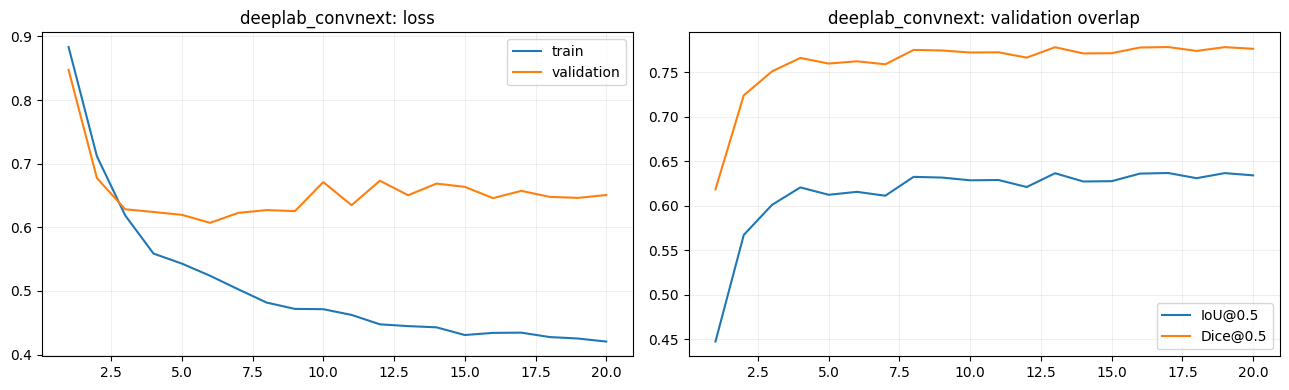

In [ ]:
for model_key in MODEL_SPECS:
    history_path = SAVE_ROOT / "development" / model_key / "history.csv"
    if not history_path.exists():
        continue
    h=pd.read_csv(history_path)
    fig,axes=plt.subplots(1,2,figsize=(13,4))
    axes[0].plot(h.epoch,h.train_loss,label="train")
    axes[0].plot(h.epoch,h.val_loss,label="validation")
    axes[0].set_title(f"{model_key}: loss")
    axes[0].legend(); axes[0].grid(alpha=.2)
    axes[1].plot(h.epoch,h.val_iou_050,label="IoU@0.5")
    axes[1].plot(h.epoch,h.val_dice_050,label="Dice@0.5")
    axes[1].set_title(f"{model_key}: validation overlap")
    axes[1].legend(); axes[1].grid(alpha=.2)
    plt.tight_layout(); plt.show()

In [ ]:
def normalize_image_np(img_hwc):
    t=torch.from_numpy(img_hwc.astype(np.float32)/255.0).permute(2,0,1)
    return (t-IMAGENET_MEAN)/IMAGENET_STD

def infer_starts(size, patch=PATCH_SIZE, stride=INFER_STRIDE):
    starts=list(range(0,size-patch+1,stride))
    final=size-patch
    if not starts or starts[-1]!=final: starts.append(final)
    return starts

_h=np.hanning(PATCH_SIZE).astype(np.float32)
HANN_2D=np.outer(_h,_h)
HANN_2D=np.clip(HANN_2D,0.05,None)
HANN_2D=HANN_2D/HANN_2D.max()

def _tta_pairs(mode):
    if mode == "none":
        return [(lambda x:x, lambda y:y)]
    if mode == "4way":
        return [
            (lambda x:x, lambda y:y),
            (lambda x:torch.flip(x,[3]), lambda y:torch.flip(y,[3])),
            (lambda x:torch.flip(x,[2]), lambda y:torch.flip(y,[2])),
            (lambda x:torch.flip(x,[2,3]), lambda y:torch.flip(y,[2,3])),
        ]
    if mode == "d4":
        pairs=[]
        for k in range(4):
            pairs.append((
                lambda x,k=k: torch.rot90(x,k,[2,3]),
                lambda y,k=k: torch.rot90(y,(-k)%4,[2,3]),
            ))
            pairs.append((
                lambda x,k=k: torch.flip(torch.rot90(x,k,[2,3]),[3]),
                lambda y,k=k: torch.rot90(torch.flip(y,[3]),(-k)%4,[2,3]),
            ))
        return pairs
    raise ValueError(mode)

@torch.no_grad()
def predict_batch_tta(model,batch):
    batch=batch.to(DEVICE,non_blocking=True)
    total=None
    pairs=_tta_pairs(TTA_MODE)
    for forward_t, inverse_t in pairs:
        aug=forward_t(batch)
        with autocast_context():
            p=torch.sigmoid(model(aug))
        p=inverse_t(p)
        total=p if total is None else total+p
    return (total/len(pairs)).float().cpu().numpy()[:,0]

@torch.no_grad()
def predict_full_tile(model,image_path,inference_batch_size=INFERENCE_BATCH_SIZE):
    with rasterio.open(image_path) as src:
        h,w=src.height,src.width
        ys=infer_starts(h); xs=infer_starts(w)
        prob_sum=np.zeros((h,w),dtype=np.float32)
        weight_sum=np.zeros((h,w),dtype=np.float32)
        patches=[]; coords=[]

        def flush():
            nonlocal patches,coords
            if not patches: return
            batch=torch.stack(patches)
            probs=predict_batch_tta(model,batch)
            for p,(x,y) in zip(probs,coords):
                prob_sum[y:y+PATCH_SIZE,x:x+PATCH_SIZE] += p*HANN_2D
                weight_sum[y:y+PATCH_SIZE,x:x+PATCH_SIZE] += HANN_2D
            patches=[]; coords=[]

        for y in ys:
            for x in xs:
                arr=src.read([1,2,3],window=Window(x,y,PATCH_SIZE,PATCH_SIZE)).transpose(1,2,0)
                patches.append(normalize_image_np(arr)); coords.append((x,y))
                if len(patches)>=inference_batch_size: flush()
        flush()

    assert np.all(weight_sum>0)
    return prob_sum/weight_sum

def checkpoint_cache_tag(checkpoint_path):
    checkpoint_path=Path(checkpoint_path)
    ckpt=safe_torch_load(checkpoint_path,"cpu")
    epoch=ckpt.get("epoch","x")
    st=checkpoint_path.stat()
    return f"e{epoch}_s{st.st_size}_m{st.st_mtime_ns}"

def cache_model_predictions(model_key, checkpoint_path, pairs, cache_dir):
    cache_dir=Path(cache_dir); cache_dir.mkdir(parents=True,exist_ok=True)
    model=build_model(model_key,pretrained=False)
    ckpt=safe_torch_load(checkpoint_path,"cpu")
    model.load_state_dict(ckpt["model"])
    model=model.to(DEVICE).eval()

    for row in tqdm(pairs.itertuples(index=False),total=len(pairs),desc=f"Caching {model_key}"):
        out=cache_dir/f"{row.tile}.npy"
        if out.exists():
            continue
        prob=predict_full_tile(model,row.image)
        np.save(out,prob.astype(np.float16))
        del prob; gc.collect()

    del model,ckpt
    gc.collect()
    if DEVICE.type=="cuda": torch.cuda.empty_cache()

In [ ]:
RUN_VALIDATION_CACHE = True

VAL_CACHE_DIRS = {}
for model_key in MODEL_SPECS:
    if model_key not in DEV_BEST_PATHS:
        print(f"[skip] {model_key}: no checkpoint")
        continue

    tag = checkpoint_cache_tag(DEV_BEST_PATHS[model_key])
    d = CACHE_ROOT / "validation" / model_key / tag
    VAL_CACHE_DIRS[model_key] = d

    if RUN_VALIDATION_CACHE:
        print(f"[{model_key}] caching to {d}")
        cache_model_predictions(model_key, DEV_BEST_PATHS[model_key], dev_val_pairs_run, d)
    else:
        expected = [f"{t}.npy" for t in dev_val_pairs_run.tile]
        missing = [n for n in expected if not (d / n).exists()]
        assert not missing, f"{model_key}: {len(missing)}/{len(expected)} missing in {d}"

[deeplab_convnext] caching to /content/inria_prediction_cache_competition_v2/validation/deeplab_convnext/e17_s117328258_m1789214270000000000


Caching deeplab_convnext:   0%|          | 0/36 [00:00<?, ?it/s]

[skip] segformer_mit: no checkpoint


In [ ]:

CANDIDATE_KEYS = ["deeplab_convnext", "segformer_mit"]
MODEL_KEYS = [
    k for k in CANDIDATE_KEYS
    if k in DEV_BEST_PATHS
    and k in VAL_CACHE_DIRS
    and VAL_CACHE_DIRS[k].exists()
    and any(VAL_CACHE_DIRS[k].glob("*.npy"))
]
print("Models used:", MODEL_KEYS)
if not MODEL_KEYS:
    raise RuntimeError("No cached model predictions found.")


rng = np.random.default_rng(SEED)
sampled_preds = {k: [] for k in MODEL_KEYS}
sampled_y = []

for row in tqdm(dev_val_pairs_run.itertuples(index=False),
                total=len(dev_val_pairs_run), desc="Sampling validation pixels"):
    preds = {k: np.load(VAL_CACHE_DIRS[k] / f"{row.tile}.npy", mmap_mode="r")
             for k in MODEL_KEYS}
    with rasterio.open(row.mask) as src:
        gt = (src.read(1) > 127).reshape(-1)

    n = gt.size
    k_pix = min(TUNING_SAMPLE_PIXELS_PER_TILE, n)
    idx = rng.choice(n, size=k_pix, replace=False)

    for k in MODEL_KEYS:
        sampled_preds[k].append(np.asarray(preds[k]).reshape(-1)[idx].astype(np.float32))
    sampled_y.append(gt[idx])

ys = np.concatenate(sampled_y).astype(bool)
P  = {k: np.concatenate(v) for k, v in sampled_preds.items()}
print("Tuning pixels:", len(ys), "foreground fraction:", ys.mean())



def threshold_metrics_from_hist(pos_hist, neg_hist, thresholds, nbins=1001):
    pos_rev = np.cumsum(pos_hist[::-1])[::-1]
    neg_rev = np.cumsum(neg_hist[::-1])[::-1]
    pos_total = pos_hist.sum()
    neg_total = neg_hist.sum()
    rows = []
    for t in thresholds:
        b = int(np.clip(round(float(t) * (nbins - 1)), 0, nbins - 1))
        tp = int(pos_rev[b]); fp = int(neg_rev[b])
        fn = int(pos_total - tp); tn = int(neg_total - fp)
        rows.append({"threshold": float(t), **metrics_from_counts(tp, fp, fn, tn)})
    return rows



search_rows = []
NBINS = 1001
WEIGHT_GRID = list(ENSEMBLE_WEIGHTS) if len(MODEL_KEYS) >= 2 else [1.0]

for w in tqdm(WEIGHT_GRID, desc="Ensemble grid"):
    if len(MODEL_KEYS) >= 2:
        pe = w * P["deeplab_convnext"] + (1.0 - w) * P["segformer_mit"]
    else:
        pe = P[MODEL_KEYS[0]]
    bins = np.clip((pe * (NBINS - 1)).astype(np.int32), 0, NBINS - 1)
    pos_hist = np.bincount(bins[ys],  minlength=NBINS)
    neg_hist = np.bincount(bins[~ys], minlength=NBINS)
    for r in threshold_metrics_from_hist(pos_hist, neg_hist, THRESHOLDS, NBINS):
        search_rows.append({"deeplab_weight": float(w), **r})

grid_df = pd.DataFrame(search_rows)
best_row = grid_df.loc[grid_df.iou.idxmax()]
BEST_DEEPLAB_WEIGHT = float(best_row.deeplab_weight)
BEST_THRESHOLD      = float(best_row.threshold)

print("Sample-selected DeepLab weight:", BEST_DEEPLAB_WEIGHT)
print("Sample-selected threshold     :", BEST_THRESHOLD)
print("Sample IoU                    :", float(best_row.iou))



def ensemble_pred(tile):
    p1 = np.load(VAL_CACHE_DIRS[MODEL_KEYS[0]] / f"{tile}.npy").astype(np.float32)
    if len(MODEL_KEYS) >= 2:
        p2 = np.load(VAL_CACHE_DIRS[MODEL_KEYS[1]] / f"{tile}.npy").astype(np.float32)
        return BEST_DEEPLAB_WEIGHT * p1 + (1.0 - BEST_DEEPLAB_WEIGHT) * p2
    return p1



tp = fp = fn = tn = 0
for row in tqdm(dev_val_pairs_run.itertuples(index=False),
                total=len(dev_val_pairs_run), desc="Exact validation check"):
    pe = ensemble_pred(row.tile)
    pred = pe >= BEST_THRESHOLD
    with rasterio.open(row.mask) as src:
        gt = src.read(1) > 127
    tp += int(np.logical_and(pred,  gt).sum())
    fp += int(np.logical_and(pred, ~gt).sum())
    fn += int(np.logical_and(~pred, gt).sum())
    tn += int(np.logical_and(~pred, ~gt).sum())
    del pe, pred, gt

VALIDATION_METRICS = metrics_from_counts(tp, fp, fn, tn)
print("Exact full-validation metrics before post-processing:",
      json.dumps(VALIDATION_METRICS, indent=2))



MIN_COMPONENT_AREA = 0
POSTPROCESS_VALIDATION = {}
if TUNE_POSTPROCESS:
    pp_counts = {a: {"tp": 0, "fp": 0, "fn": 0, "tn": 0} for a in POSTPROCESS_CANDIDATES}
    for row in tqdm(dev_val_pairs_run.itertuples(index=False),
                    total=len(dev_val_pairs_run), desc="Tuning small-component filter"):
        raw = ensemble_pred(row.tile) >= BEST_THRESHOLD
        with rasterio.open(row.mask) as src:
            gt = src.read(1) > 127
        labels, nlab = ndimage.label(raw)
        sizes = np.bincount(labels.ravel()) if nlab > 0 else np.array([raw.size])
        for area in POSTPROCESS_CANDIDATES:
            if area <= 0:
                pred = raw
            elif nlab == 0:
                pred = raw
            else:
                keep = sizes >= area
                keep[0] = False
                pred = keep[labels]
            d = pp_counts[area]
            d["tp"] += int(np.logical_and(pred,  gt).sum())
            d["fp"] += int(np.logical_and(pred, ~gt).sum())
            d["fn"] += int(np.logical_and(~pred, gt).sum())
            d["tn"] += int(np.logical_and(~pred, ~gt).sum())
        del raw, gt, labels

    pp_rows = []
    for area, c in pp_counts.items():
        pp_rows.append({"min_component_area": area,
                        **metrics_from_counts(c["tp"], c["fp"], c["fn"], c["tn"])})
    pp_df = pd.DataFrame(pp_rows).sort_values("iou", ascending=False)
    MIN_COMPONENT_AREA = int(pp_df.iloc[0].min_component_area)
    POSTPROCESS_VALIDATION = pp_df.iloc[0].to_dict()
    display(pp_df)
    pp_df.to_csv(SAVE_ROOT / "postprocess_validation_grid.csv", index=False)
    print("Selected min component area:", MIN_COMPONENT_AREA)
    VALIDATION_METRICS = {k: float(POSTPROCESS_VALIDATION[k])
                          for k in ["iou", "dice", "precision", "recall", "accuracy"]}



TUNING_CONFIG = {
    "models": MODEL_KEYS,
    "deeplab_weight": BEST_DEEPLAB_WEIGHT,
    "segformer_weight": 1.0 - BEST_DEEPLAB_WEIGHT,
    "threshold": BEST_THRESHOLD,
    "validation_metrics": VALIDATION_METRICS,
    "tta_mode": TTA_MODE,
    "infer_stride": INFER_STRIDE,
    "min_component_area": int(MIN_COMPONENT_AREA),
}
with open(SAVE_ROOT / "validation_selected_config.json", "w") as f:
    json.dump(TUNING_CONFIG, f, indent=2)
grid_df.to_csv(SAVE_ROOT / "ensemble_threshold_grid_sample.csv", index=False)

display(grid_df.sort_values("iou", ascending=False).head(12))

Models used: ['deeplab_convnext']


Sampling validation pixels:   0%|          | 0/36 [00:00<?, ?it/s]

Tuning pixels: 3600000 foreground fraction: 0.048488611111111114


Ensemble grid:   0%|          | 0/1 [00:00<?, ?it/s]

Sample-selected DeepLab weight: 1.0
Sample-selected threshold     : 0.44
Sample IoU                    : 0.6492015991505968


Exact validation check:   0%|          | 0/36 [00:00<?, ?it/s]

Exact full-validation metrics before post-processing: {
  "iou": 0.649688505736032,
  "dice": 0.787649915092503,
  "precision": 0.7835187745801869,
  "recall": 0.7918248497867808,
  "accuracy": 0.9792721988888888
}


,deeplab_weight,threshold,iou,dice,precision,recall,accuracy
24,1.0,0.44,0.649202,0.787292,0.782974,0.791658,0.979258
25,1.0,0.45,0.649185,0.787280,0.786006,0.788559,0.979337
23,1.0,0.43,0.649078,0.787201,0.779931,0.794608,0.979169
26,1.0,0.46,0.649052,0.787182,0.788976,0.785396,0.979408
27,1.0,0.47,0.648916,0.787082,0.791856,0.782366,0.979476
22,1.0,0.42,0.648804,0.786999,0.776858,0.797409,0.979071
21,1.0,0.41,0.648696,0.786920,0.773780,0.800514,0.978979
28,1.0,0.48,0.648589,0.786841,0.794588,0.779244,0.979528
20,1.0,0.40,0.648516,0.786788,0.770615,0.803654,0.978880
19,1.0,0.39,0.648186,0.786545,0.767417,0.806650,0.978771


In [ ]:
FINAL_PATHS = {}


MODELS_TO_FINALIZE = [k for k in MODEL_SPECS if k in DEV_BEST_PATHS]
print("Finalizing:", MODELS_TO_FINALIZE)

for model_key in MODELS_TO_FINALIZE:
    if RUN_FINAL_REFIT:
        dev_ckpt = safe_torch_load(DEV_BEST_PATHS[model_key], "cpu")
        selected_epochs = max(int(dev_ckpt["epoch"]), 1)
        print(model_key, "selected final epochs:", selected_epochs)
        FINAL_PATHS[model_key] = train_final_refit(
            model_key, final_train_index, FINAL_POS_WEIGHT, selected_epochs
        )
    else:
        FINAL_PATHS[model_key] = DEV_BEST_PATHS[model_key]

print(FINAL_PATHS)

Finalizing: ['deeplab_convnext']
{'deeplab_convnext': PosixPath('/content/drive/MyDrive/inria_building_competition_v2/development/deeplab_convnext/best.pt')}


In [ ]:
def train_final_refit(model_key, train_index, pos_weight, epochs):
    model_dir = SAVE_ROOT / "final_refit" / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    final_path = model_dir / "final.pt"
    last_path  = model_dir / "last.pt"

    if final_path.exists() and RESUME_TRAINING:
        print("Final checkpoint already exists:", final_path)
        return final_path

    loader, _ = make_loaders(train_index, None, FINAL_SAMPLES_PER_EPOCH)
    model = build_model(model_key, pretrained=True).to(DEVICE)
    criterion = CompetitionLoss(pos_weight).to(DEVICE)
    optimizer, scheduler = make_optimizer_and_scheduler(model, epochs)
    start = 1

    if RESUME_TRAINING and last_path.exists():
        ckpt = safe_torch_load(last_path, DEVICE)
        if ckpt.get("model_spec") not in (None, MODEL_SPECS[model_key]):
            raise RuntimeError(f"Final-refit checkpoint architecture mismatch for {model_key}.")
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        if "scaler" in ckpt:
            scaler.load_state_dict(ckpt["scaler"])
        start = ckpt["epoch"] + 1
        print(f"Resuming final refit {model_key} from epoch {start}")

    epoch = start - 1
    for epoch in range(start, epochs + 1):
        print(f"\n[FINAL {model_key}] Epoch {epoch}/{epochs}")
        loss = train_one_epoch(model, loader, optimizer, criterion)
        scheduler.step()
        print("train_loss=", loss)
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "scaler": scaler.state_dict(),
            "model_key": model_key,
            "model_spec": MODEL_SPECS[model_key],
        }, last_path)

    torch.save({
        "epoch": epochs,
        "model": model.state_dict(),
        "model_key": model_key,
        "model_spec": MODEL_SPECS[model_key],
        "pos_weight": pos_weight,
        "trained_cities": FINAL_TRAIN_CITIES,
    }, final_path)

    del model, criterion, optimizer, scheduler, loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return final_path

print(FINAL_PATHS)

{'deeplab_convnext': PosixPath('/content/drive/MyDrive/inria_building_competition_v2/development/deeplab_convnext/best.pt')}


In [ ]:
with open(SAVE_ROOT / "validation_selected_config.json") as f:
    TUNING_CONFIG = json.load(f)
BEST_DEEPLAB_WEIGHT = float(TUNING_CONFIG["deeplab_weight"])
BEST_THRESHOLD       = float(TUNING_CONFIG["threshold"])
MIN_COMPONENT_AREA   = int(TUNING_CONFIG.get("min_component_area", 0))


MODELS_TO_PREDICT = [k for k in MODEL_SPECS if k in FINAL_PATHS]
print("Predicting with:", MODELS_TO_PREDICT)

TEST_CACHE_DIRS = {}
for model_key in MODELS_TO_PREDICT:
    tag = checkpoint_cache_tag(FINAL_PATHS[model_key])
    d = CACHE_ROOT / "test" / model_key / tag
    TEST_CACHE_DIRS[model_key] = d

    expected = [f"{t}.npy" for t in test_pairs_run.tile]

    if RUN_TEST_CACHE:
        print(f"[{model_key}] caching predictions -> {d}")
        cache_model_predictions(model_key, FINAL_PATHS[model_key], test_pairs_run, d)
        missing = [n for n in expected if not (d / n).exists()]
        assert not missing, (
            f"{model_key}: cache_model_predictions ran but {len(missing)}/{len(expected)} "
            f"still missing in {d}; first: {missing[:3]}"
        )
    else:
        missing = [n for n in expected if not (d / n).exists()]
        assert not missing, (
            f"{model_key}: {len(missing)}/{len(expected)} missing in {d}; "
            f"first: {missing[:3]} — set RUN_TEST_CACHE = True to populate it."
        )

print(TEST_CACHE_DIRS)

Predicting with: ['deeplab_convnext']
[deeplab_convnext] caching predictions -> /content/inria_prediction_cache_competition_v2/test/deeplab_convnext/e17_s117328258_m1789214270000000000


Caching deeplab_convnext:   0%|          | 0/36 [00:00<?, ?it/s]

{'deeplab_convnext': PosixPath('/content/inria_prediction_cache_competition_v2/test/deeplab_convnext/e17_s117328258_m1789214270000000000')}


In [ ]:
def mask_boundary(mask):
    mask = mask.astype(bool)
    eroded = ndimage.binary_erosion(mask, structure=np.ones((3, 3), dtype=bool), border_value=0)
    return np.logical_and(mask, ~eroded)


def boundary_match_counts(pred, gt, tolerance_px=BOUNDARY_TOLERANCE_PX):
    pb = mask_boundary(pred)
    gb = mask_boundary(gt)
    gb_tol = ndimage.binary_dilation(gb, iterations=tolerance_px)
    pb_tol = ndimage.binary_dilation(pb, iterations=tolerance_px)
    return (
        int(np.logical_and(pb, gb_tol).sum()), int(pb.sum()),
        int(np.logical_and(gb, pb_tol).sum()), int(gb.sum()),
    )


def remove_small_components(mask, min_area):
    if min_area <= 0:
        return mask
    labels, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(labels.ravel())
    keep = sizes >= min_area
    keep[0] = False
    return keep[labels]


def patch_iou(pred, gt, eps=1e-8):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return 1.0 if union == 0 else float(inter / (union + eps))


def qualitative_starts(size=5000, patch=PATCH_SIZE):
    s = list(range(0, size - patch + 1, patch))
    final = size - patch
    if s[-1] != final:
        s.append(final)
    return s


CANDIDATE_KEYS = ["deeplab_convnext", "segformer_mit"]
MODEL_KEYS = [
    k for k in CANDIDATE_KEYS
    if k in TEST_CACHE_DIRS
    and TEST_CACHE_DIRS[k].exists()
    and any(TEST_CACHE_DIRS[k].glob("*.npy"))
]
print("Models used at test time:", MODEL_KEYS)
if not MODEL_KEYS:
    raise RuntimeError("No cached test predictions found.")


def ensemble_pred(tile):
    p1 = np.load(TEST_CACHE_DIRS[MODEL_KEYS[0]] / f"{tile}.npy").astype(np.float32)
    if len(MODEL_KEYS) >= 2:
        p2 = np.load(TEST_CACHE_DIRS[MODEL_KEYS[1]] / f"{tile}.npy").astype(np.float32)
        return BEST_DEEPLAB_WEIGHT * p1 + (1.0 - BEST_DEEPLAB_WEIGHT) * p2
    return p1


QUAL_STARTS = qualitative_starts()
global_tp = global_fp = global_fn = global_tn = 0
matched_pred_total = pred_boundary_total = matched_gt_total = gt_boundary_total = 0
per_tile = []
best_case = None
worst_case = None

for row in tqdm(test_pairs_run.itertuples(index=False),
                total=len(test_pairs_run), desc="FINAL TEST"):
    prob = ensemble_pred(row.tile)
    pred = remove_small_components(prob >= BEST_THRESHOLD, MIN_COMPONENT_AREA)
    with rasterio.open(row.mask) as src:
        gt = src.read(1) > 127

    tp = int(np.logical_and(pred,  gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())
    global_tp += tp; global_fp += fp; global_fn += fn; global_tn += tn
    per_tile.append({"tile": row.tile, **metrics_from_counts(tp, fp, fn, tn)})

    b = boundary_match_counts(pred, gt)
    matched_pred_total += b[0]; pred_boundary_total += b[1]
    matched_gt_total   += b[2]; gt_boundary_total   += b[3]

    for y in QUAL_STARTS:
        for x in QUAL_STARTS:
            g = gt[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            if g.mean() < 0.01:
                continue
            p = pred[y:y + PATCH_SIZE, x:x + PATCH_SIZE]
            iou = patch_iou(p, g)
            cand = {
                "iou": iou, "tile": row.tile, "image": row.image, "mask": row.mask,
                "x": x, "y": y, "pred": p.copy(),
            }
            if best_case is None or iou > best_case["iou"]:
                best_case = cand
            if worst_case is None or iou < worst_case["iou"]:
                worst_case = cand

    del prob, pred, gt
    gc.collect()

TEST_METRICS = metrics_from_counts(global_tp, global_fp, global_fn, global_tn)
bp = matched_pred_total / max(pred_boundary_total, 1)
br = matched_gt_total   / max(gt_boundary_total, 1)
bf1 = 2 * bp * br / max(bp + br, 1e-8)
TEST_METRICS.update({
    "boundary_precision": bp,
    "boundary_recall": br,
    "boundary_f1": bf1,
    "threshold": BEST_THRESHOLD,
    "deeplab_weight": BEST_DEEPLAB_WEIGHT,
    "boundary_tolerance_px": BOUNDARY_TOLERANCE_PX,
    "min_component_area": MIN_COMPONENT_AREA,
    "models": MODEL_KEYS,
})

print(json.dumps(TEST_METRICS, indent=2))
with open(SAVE_ROOT / "final_test_metrics.json", "w") as f:
    json.dump(TEST_METRICS, f, indent=2)
pd.DataFrame(per_tile).to_csv(SAVE_ROOT / "per_tile_test_metrics.csv", index=False)

Models used at test time: ['deeplab_convnext']


FINAL TEST:   0%|          | 0/36 [00:00<?, ?it/s]

{
  "iou": 0.7927937333278691,
  "dice": 0.8844226958070045,
  "precision": 0.8741367295671282,
  "recall": 0.8949536143140535,
  "accuracy": 0.9863317166666666,
  "boundary_precision": 0.74315924216041,
  "boundary_recall": 0.6686959305441037,
  "boundary_f1": 0.7039639342425841,
  "threshold": 0.44,
  "deeplab_weight": 1.0,
  "boundary_tolerance_px": 3,
  "min_component_area": 0,
  "models": [
    "deeplab_convnext"
  ]
}


In [ ]:
from pathlib import Path

cache_dir = TEST_CACHE_DIRS["deeplab_convnext"]
print("Cache dir:", cache_dir)

cached_tiles = {p.stem for p in cache_dir.glob("*.npy")}
needed_tiles = set(test_pairs_run["tile"])

missing = needed_tiles - cached_tiles
extra = cached_tiles - needed_tiles

print(f"Cached: {len(cached_tiles)}, Needed: {len(needed_tiles)}")
print(f"Missing ({len(missing)}):", sorted(missing)[:20])
print(f"Extra ({len(extra)}):", sorted(extra)[:20])


parent = cache_dir.parent
print("\nSibling run folders under", parent)
for d in parent.iterdir():
    if d.is_dir():
        n = len(list(d.glob("*.npy")))
        print(f"  {d.name}: {n} files")

Cache dir: /content/inria_prediction_cache_competition_v2/test/deeplab_convnext/e17_s117328258_m1789214270000000000
Cached: 36, Needed: 36
Missing (0): []
Extra (0): []

Sibling run folders under /content/inria_prediction_cache_competition_v2/test/deeplab_convnext
  e17_s117328258_m1789214270000000000: 36 files




Error map colors:
- Green = true positive
- Red = false positive
- Blue = false negative

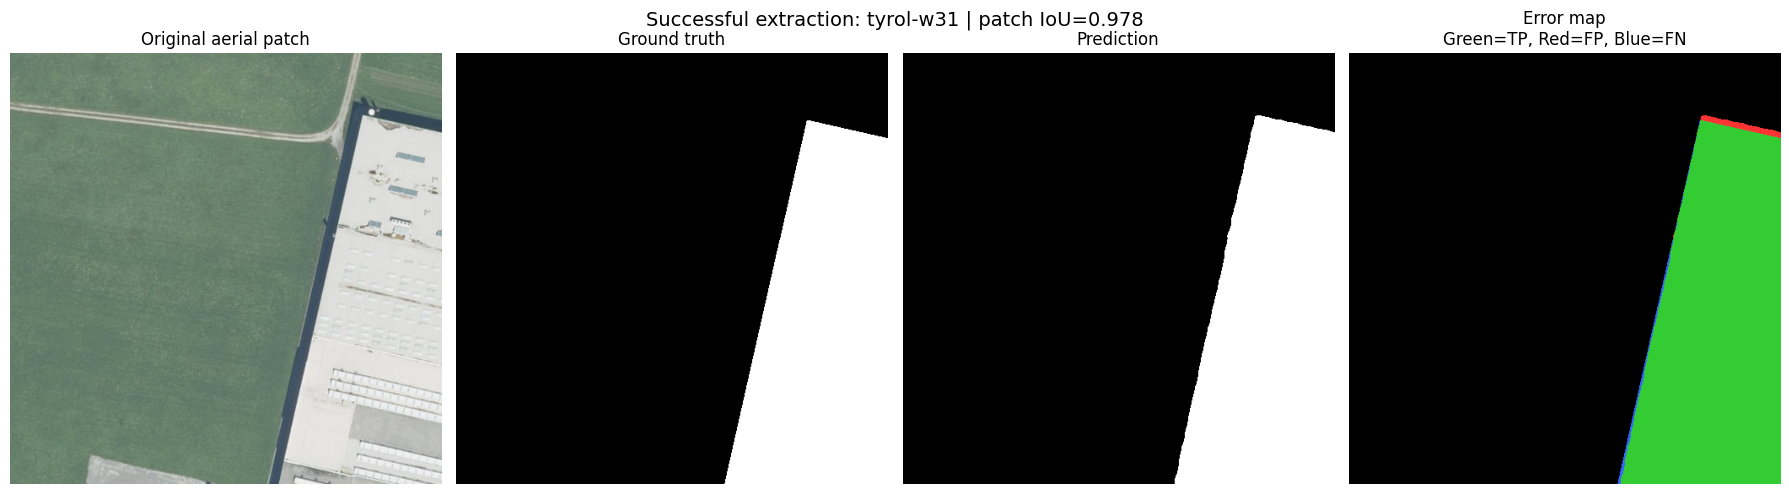

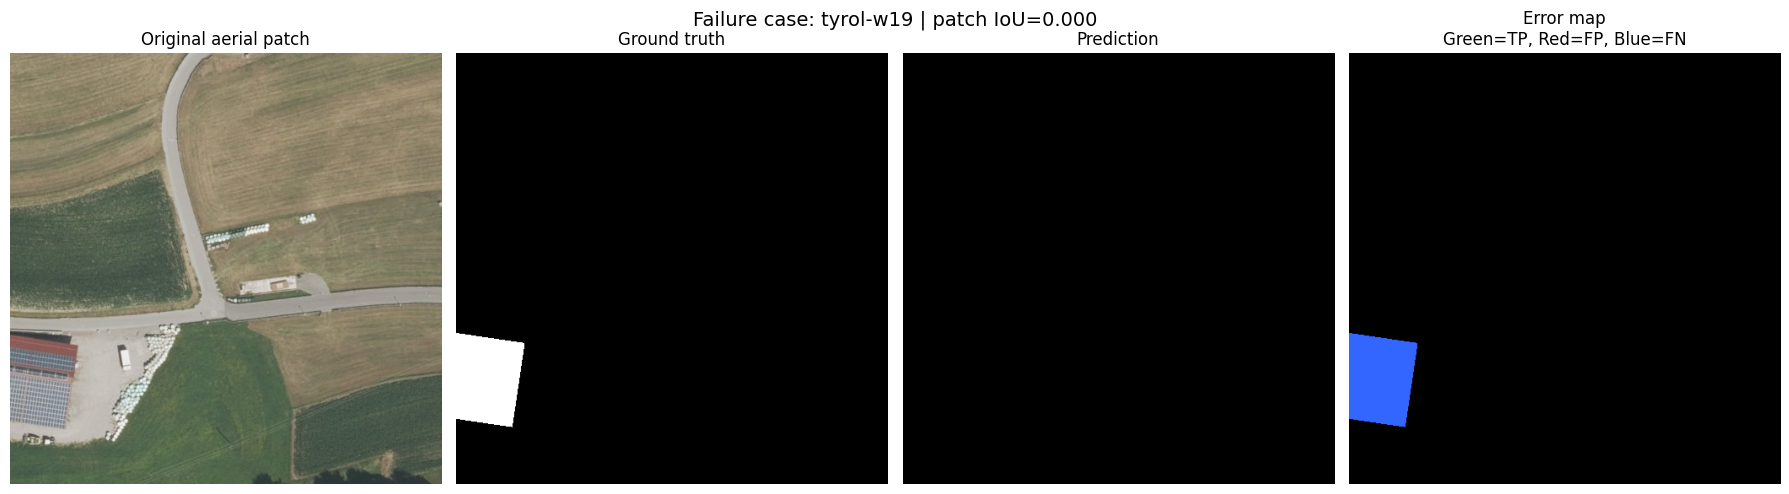

In [ ]:
def load_case(case):
    win=Window(case["x"],case["y"],PATCH_SIZE,PATCH_SIZE)
    with rasterio.open(case["image"]) as src:
        img=src.read([1,2,3],window=win).transpose(1,2,0)
    with rasterio.open(case["mask"]) as src:
        gt=src.read(1,window=win)>127
    return img,gt,case["pred"]

def plot_case(case,title,filename):
    img,gt,pred=load_case(case)
    err=np.zeros((PATCH_SIZE,PATCH_SIZE,3),dtype=np.float32)
    err[np.logical_and(pred,gt)]=[0.2,0.8,0.2]
    err[np.logical_and(pred,~gt)]=[1.0,0.2,0.2]
    err[np.logical_and(~pred,gt)]=[0.2,0.4,1.0]

    fig,axes=plt.subplots(1,4,figsize=(18,5))
    axes[0].imshow(img); axes[0].set_title("Original aerial patch")
    axes[1].imshow(gt,cmap="gray"); axes[1].set_title("Ground truth")
    axes[2].imshow(pred,cmap="gray"); axes[2].set_title("Prediction")
    axes[3].imshow(err); axes[3].set_title("Error map\nGreen=TP, Red=FP, Blue=FN")
    for ax in axes: ax.axis("off")
    fig.suptitle(f"{title}: {case['tile']} | patch IoU={case['iou']:.3f}",fontsize=14)
    plt.tight_layout()
    plt.savefig(SAVE_ROOT/filename,dpi=180,bbox_inches="tight")
    plt.show()

assert best_case is not None and worst_case is not None
plot_case(best_case,"Successful extraction","qualitative_success.png")
plot_case(worst_case,"Failure case","qualitative_failure.png")

##final table and experiment summary

In [ ]:
results_table=pd.DataFrame([
    ["Building IoU / Jaccard",TEST_METRICS["iou"]],
    ["Dice / F1",TEST_METRICS["dice"]],
    ["Precision",TEST_METRICS["precision"]],
    ["Recall",TEST_METRICS["recall"]],
    ["Pixel Accuracy",TEST_METRICS["accuracy"]],
    ["Boundary Precision",TEST_METRICS["boundary_precision"]],
    ["Boundary Recall",TEST_METRICS["boundary_recall"]],
    ["Boundary F1",TEST_METRICS["boundary_f1"]],
],columns=["Metric","Score"])
results_table["Percent"]=(100*results_table.Score).round(2)
display(results_table)
results_table.to_csv(SAVE_ROOT/"final_results_table.csv",index=False)

summary=f"""
BUILDING FOOTPRINT SEGMENTATION — COMPETITION PIPELINE

Dataset:
Inria Aerial Image Labeling Dataset, 180 publicly labelled 5000x5000 RGB tiles,
0.3 m spatial resolution.

Leakage prevention:
City-level partition is completed before any patch extraction.
Development train: {', '.join(DEV_TRAIN_CITIES)}
Validation: {', '.join(DEV_VAL_CITIES)}
Final held-out evaluation: {', '.join(TEST_CITIES)}

Competitive models:
1) DeepLabV3+ with {MODEL_SPECS['deeplab_convnext']['encoder']} encoder
2) SegFormer with {MODEL_SPECS['segformer_mit']['encoder']} encoder
Only generic ImageNet encoder pretraining is used; no Inria-trained checkpoint is used.

Loss:
{BCE_WEIGHT:.2f} Weighted BCE + {DICE_WEIGHT:.2f} Dice +
{LOVASZ_WEIGHT:.2f} Lovasz + {BOUNDARY_WEIGHT:.2f} Boundary Dice.

Inference:
Patch size={PATCH_SIZE}; stride={INFER_STRIDE}; TTA={TTA_MODE}; Hann overlap blending.
Validation-selected ensemble:
DeepLab weight={BEST_DEEPLAB_WEIGHT:.2f}; SegFormer weight={1-BEST_DEEPLAB_WEIGHT:.2f};
threshold={BEST_THRESHOLD:.2f}; min component area={MIN_COMPONENT_AREA} px.

Final held-out West Tyrol:
IoU={TEST_METRICS['iou']:.4f}
Dice/F1={TEST_METRICS['dice']:.4f}
Precision={TEST_METRICS['precision']:.4f}
Recall={TEST_METRICS['recall']:.4f}
Boundary F1={TEST_METRICS['boundary_f1']:.4f}
Pixel accuracy={TEST_METRICS['accuracy']:.4f}
""".strip()

print(summary)
with open(SAVE_ROOT/"report_summary.txt","w") as f: f.write(summary)

,Metric,Score,Percent
0,Building IoU / Jaccard,0.792794,79.28
1,Dice / F1,0.884423,88.44
2,Precision,0.874137,87.41
3,Recall,0.894954,89.50
4,Pixel Accuracy,0.986332,98.63
5,Boundary Precision,0.743159,74.32
6,Boundary Recall,0.668696,66.87
7,Boundary F1,0.703964,70.40


BUILDING FOOTPRINT SEGMENTATION — COMPETITION PIPELINE

Dataset:
Inria Aerial Image Labeling Dataset, 180 publicly labelled 5000x5000 RGB tiles,
0.3 m spatial resolution.

Leakage prevention:
City-level partition is completed before any patch extraction.
Development train: austin, chicago, vienna
Validation: kitsap
Final held-out evaluation: tyrol-w

Competitive models:
1) DeepLabV3+ with tu-convnext_tiny encoder
2) SegFormer with mit_b2 encoder
Only generic ImageNet encoder pretraining is used; no Inria-trained checkpoint is used.

Loss:
0.30 Weighted BCE + 0.30 Dice +
0.30 Lovasz + 0.10 Boundary Dice.

Inference:
Patch size=512; stride=256; TTA=4way; Hann overlap blending.
Validation-selected ensemble:
DeepLab weight=1.00; SegFormer weight=0.00;
threshold=0.44; min component area=0 px.

Final held-out West Tyrol:
IoU=0.7928
Dice/F1=0.8844
Precision=0.8741
Recall=0.8950
Boundary F1=0.7040
Pixel accuracy=0.9863


In [ ]:
# # ============================================================
# # SAVE EXPERIMENT RESULTS TO LOCAL PC
# # ============================================================

# import shutil
# from pathlib import Path
# from google.colab import files

# # Your experiment output directory
# # SAVE_ROOT should already exist earlier in your notebook.
# print("SAVE_ROOT:", SAVE_ROOT)

# # Name of the ZIP file
# ZIP_NAME = "inria_training_results"

# # Remove old zip if it exists
# zip_path = Path(f"/content/{ZIP_NAME}.zip")
# if zip_path.exists():
#     zip_path.unlink()

# # Compress everything inside SAVE_ROOT
# shutil.make_archive(
#     f"/content/{ZIP_NAME}",
#     "zip",
#     root_dir=SAVE_ROOT
# )

# # Show size
# size_gb = zip_path.stat().st_size / (1024 ** 3)

# print(f"\nCreated: {zip_path}")
# print(f"ZIP size: {size_gb:.2f} GB")

# # Download to your computer
# files.download(str(zip_path))